# Assignment 3 - Building a Simplified Transformer for Sentiment Analysis

This file implement simplified Transformer from scratch to classify the perform sentiment analysis on IMDb dataset..

In [8]:
# import relevant libraries
import os # to save the result in a folder
import pickle # to save the result in pickle for further analysis
import re # to split review text into words for the custom vocabulary
import sys

import time # to track the time

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader # to prepare for DataLoader
# import torchvision.transforms as transforms # to transform the images
from datasets import load_dataset
from transformers import AutoTokenizer
from collections import Counter
import math

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from train_utils import train, test # Shared training/testing function across all notebook file


### 1. Load The IMDb Dataset, Preprocessing, and Dataset Handling

In [9]:
# load the dataset
imdb_dataset = load_dataset('stanfordnlp/imdb')

In [10]:
target_names = ['negative','positive'] # how can I know 0=negative, 1=positive?

In [11]:
# Count the label
train_label = list(imdb_dataset['train']['label'])
test_label = list(imdb_dataset['test']['label'])

In [12]:
count_train_label = Counter(train_label)
count_test_label = Counter(test_label)
print(f"The count of train label is:{count_train_label}")
print(f"\nThe count of test label is:{count_test_label}")

The count of train label is:Counter({0: 12500, 1: 12500})

The count of test label is:Counter({0: 12500, 1: 12500})


In [13]:
# Count the text length
train_length = []
test_length = []
for i in imdb_dataset['train']['text']:
    train_length.append(len(i))
for j in imdb_dataset['test']['text']:
    test_length.append(len(j))

print(f"The shortest train length (character) is {min(train_length)} chars.\nThe longest train length (character) is {max(train_length)} chars.")
print(f"\nThe shortest test length (character) is {min(test_length)} chars.\nThe longest test length (character) is {max(test_length)} chars.")

The shortest train length (character) is 52 chars.
The longest train length (character) is 13704 chars.

The shortest test length (character) is 32 chars.
The longest test length (character) is 12988 chars.


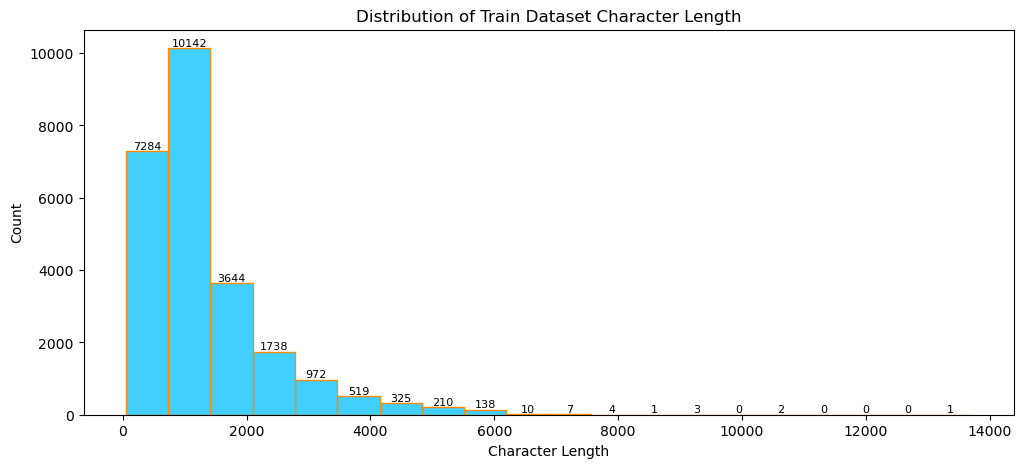

In [7]:
# visualise train dataset character length
plt.figure(figsize=(12,5))
plt.title("Distribution of Train Dataset Character Length")
plt.xlabel("Character Length")
sns_char_train = sns.histplot(data=train_length, bins=20, color='deepskyblue', edgecolor='darkorange')
sns_char_train.bar_label(sns_char_train.containers[0], fontsize=8)

plt.show()

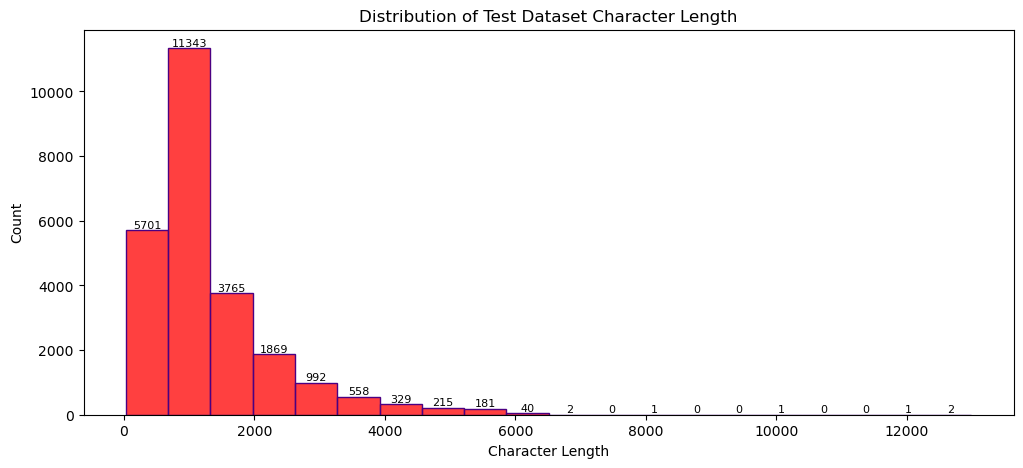

In [8]:
# visualise
plt.figure(figsize=(12,5))
plt.title("Distribution of Test Dataset Character Length")
plt.xlabel("Character Length")
sns_char_test = sns.histplot(data=test_length, bins=20, color='red', edgecolor='indigo')
sns_char_test.bar_label(sns_char_test.containers[0], fontsize=8)

plt.show()

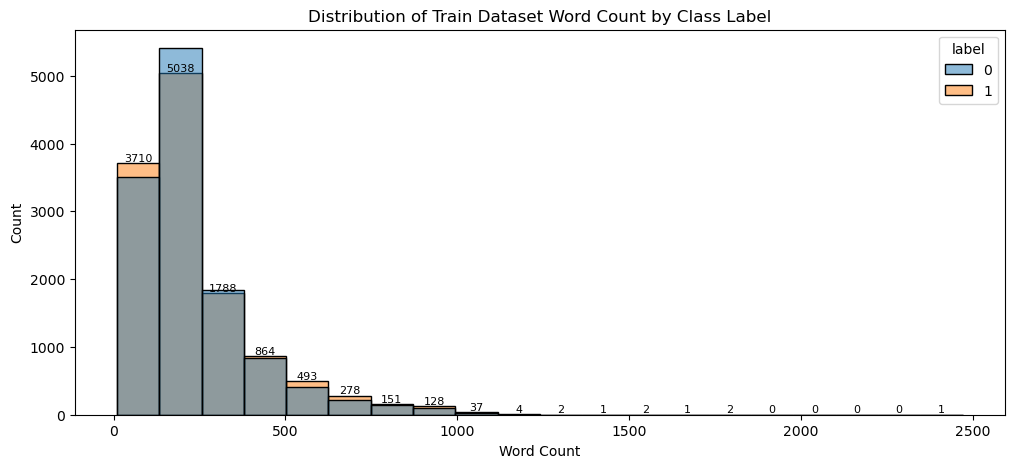

In [9]:
# Extract per words
train_word_counts = [len(text.split()) for text in imdb_dataset['train']['text']] # word count per review
train_word_labels = imdb_dataset['train']['label']

# Visualise length of words per class labels (histogram). Use class label as hue
plt.figure(figsize=(12,5))
plt.title("Distribution of Train Dataset Word Count by Class Label")
plt.xlabel("Word Count")
sns_word_train =  sns.histplot(
    data={'word_count': train_word_counts, 'label': train_word_labels},
    x='word_count',
    hue='label',
    bins=20,
    multiple='layer'
)
sns_word_train.bar_label(sns_word_train.containers[0], fontsize=8)
plt.show()

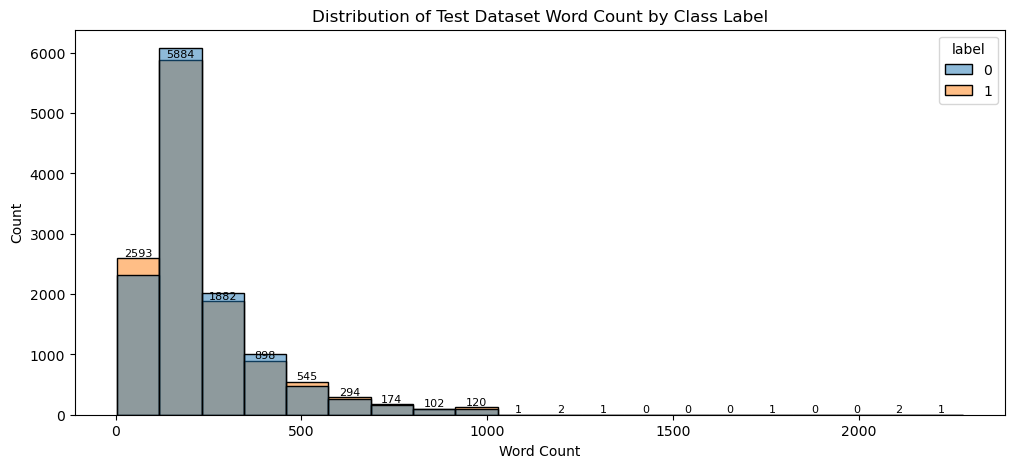

In [20]:
# Extract per words (test)
test_word_counts = [len(text.split()) for text in imdb_dataset['test']['text']] # word count per review
test_word_labels = imdb_dataset['test']['label']

# Visualise length of words per class labels (histogram). Use class label as hue
plt.figure(figsize=(12,5))
plt.title("Distribution of Test Dataset Word Count by Class Label")
plt.xlabel("Word Count")
sns_word_test = sns.histplot(
    data={'word_count': test_word_counts, 'label': test_word_labels},
    x='word_count',
    hue='label',
    bins=20,
    multiple='layer'
)

sns_word_test.bar_label(sns_word_test.containers[0], fontsize=8)
plt.show()

In [14]:
# setting the tokenizer
tokeniser_name = 'bert-base-uncased'
tokeniser = AutoTokenizer.from_pretrained(tokeniser_name)
print(tokeniser)

BertTokenizer(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})


#### Limit the tokeniser vocabulary size

The default `bert-base-uncased` vocabulary (30,522 tokens) makes the embedding table the dominant source of model parameters, which drives overfitting on this 25,000-review dataset. The cell below retrains the same WordPiece tokeniser on the IMDb train corpus with a much smaller target vocabulary.

In [15]:
# limit the vocabulary size of the tokeniser (change this value to experiment with vocab capacity later)
custom_vocab_size = 20000

def get_training_corpus(dataset, batch_size=1000):
    """
    Yield the review text in batches for the tokeniser trainer.

    Args:
        dataset: HuggingFace dataset split containing a "text" column.
        batch_size (int): Number of reviews yielded per batch.

    Returns:
        generator: Batches of raw review text strings.
    """
    for i in range(0, len(dataset["text"]), batch_size):
        yield dataset["text"][i : i + batch_size]

# retrain the bert-base-uncased WordPiece tokeniser on the IMDb train corpus, capped at custom_vocab_size tokens
tokeniser = tokeniser.train_new_from_iterator(
    get_training_corpus(imdb_dataset["train"]),
    vocab_size=custom_vocab_size
)

print(tokeniser)
print(f"New tokeniser vocab size: {tokeniser.vocab_size}")

BertTokenizer(name_or_path='bert-base-uncased', vocab_size=20000, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})
New tokeniser vocab size: 20000


In [16]:
# define the tokenisation function
def tokenise_function(examples):
    return tokeniser(
        examples["text"],
        padding = "max_length",
        truncation = True,
        max_length = 600
    )

In [17]:
# tokenise the dataset
tokenised_datasets = imdb_dataset.map(tokenise_function, batched=True)

tokenised_datasets = tokenised_datasets.select_columns(["input_ids", "attention_mask", "label"])
tokenised_datasets.set_format("torch")

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [18]:
# create PyToch DataLoaders
train_dataloader = DataLoader(
    tokenised_datasets["train"],
    batch_size=32,
    shuffle=True
)

test_dataloader = DataLoader(
    tokenised_datasets["test"],
    batch_size=32,
    shuffle=False
)

In [19]:
# show information of the datasets per batch
for batch in train_dataloader:
    print("Input IDs shape:", batch["input_ids"].shape)          # [32, 512]
    print("Attention Mask shape:", batch["attention_mask"].shape)  # [32, 512]
    print("Labels shape:", batch["label"].shape)                 # [32]
    break

Input IDs shape: torch.Size([32, 600])
Attention Mask shape: torch.Size([32, 600])
Labels shape: torch.Size([32])


### 2. Transformers Implementation

**1. Architecture Requirements**
- **Input Embedding Layer**:
    - Convert input text to token embeddings using a simple word embedding layer.
    - Use torch.nn.Embedding or implement your own.
- **Positional Encoding**:
    - Add positional encodings to input embeddings to incorporate sequential information.
- **Self-Attention Mechanism**:
    - Implement scaled dot-product attention: $$\text{Attention}(Q, K, V) = \text{softmax}\left( \frac{QK^T}{\sqrt{d_k}} \right) V$$
    - Use multi-head attention for richer feature representations.
- **Feedforward Network**:
    - Add a two-layer feedforward network with ReLU activation.
- **Classification Head**:
    - Use a fully connected layer to map the output of the Transformer to a binary label (positive or negative).
- **Architecture Summary**:
    - Input → Embedding → Positional Encoding → Multi-Head Attention → Feedforward → Classification Head → Output

**2. Forward Propagation**
- Implement tokenization, embedding, attention computation, and feedforward operations.
- Use softmax activation in the output layer for binary classification probabilities.

**3. Backward Propagation**
- Compute gradients for all weights using binary cross-entropy loss.
- Update weights using **Adam Optimizer**.

**4. Training Loop**
- Train the Transformer for **10** epochs with:
    - Batch size: **32**
    - Learning rate: **0.001**
- Use mini-batch processing.

**5. Evaluation**
- Evaluate the model on the IMDb test set.
- Calculate and report **accuracy, precision, recall, and F1-score**.

In [20]:
# make the scaled dot product attention
def scaled_dot_product_attention(query, key, value, mask=None):
    """
    Calculate dot product to get attention
    Args:
    Returns:
    """
    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k) # attention formula
    if mask is not None: # for decoder. leave it for further project
        scores = scores.masked_fill(mask == 0, -1e9)
    attn_weights = F.softmax(scores, dim=-1)
    output = torch.matmul(attn_weights, value)
    return output, attn_weights

In [21]:
class MultiHeadAttention(torch.nn.Module):
    """
    this is self-attention in this notebook, because it's always called as mha(x, x, x, mask) — query, key, and value all come from the same input x.
    Each token's representation gets updated by looking at (attending to) every other token in the sequence, including itself.
    """
    def __init__(self, num_heads, d_model):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        assert d_model % num_heads == 0
        self.depth = d_model // num_heads

        self.wq = torch.nn.Linear(d_model, d_model, )
        self.wk = torch.nn.Linear(d_model, d_model)
        self.wv = torch.nn.Linear(d_model, d_model)
        self.dense = torch.nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        return x.transpose(1, 2)

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)
        query = self.split_heads(self.wq(query), batch_size)
        key = self.split_heads(self.wk(key), batch_size)
        value = self.split_heads(self.wv(value), batch_size)

        scaled_attention, attn_weights = scaled_dot_product_attention(query, key, value, mask) # execute the matmul
        scaled_attention = scaled_attention.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        # Transposes back to (batch, seq_len, num_heads, depth) and reshapes (.view) to merge heads back into (batch, seq_len, d_model) — this is the "concatenate all heads" step from the original Transformer paper.

        output = self.dense(scaled_attention)
        return output, attn_weights

In [22]:
# build the positional encoding
class PositionalEncoding(torch.nn.Module):
    """
    Builds a fixed (non-learned) matrix pe of shape (max_len, d_model) using the classic sinusoidal formula from "Attention Is All You Need":
    """
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        # Each position gets a unique pattern of sine/cosine values across the d_model dimensions.
        # This lets the model infer relative and absolute positions, and generalizes reasonably to sequence lengths not seen during training (unlike a learned positional embedding table).

        pe = pe.unsqueeze(0) # shape (1, max_len, d_model) — batch-first
        self.register_buffer('pe', pe) # stores pe as part of the module's state (so it moves with .to(device) etc.) but explicitly not as a trainable parameter (no gradients).

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :] # slice along seq_len (dim 1), broadcast over batch (dim 0)
        return x

The encoder block of Transformers consist of (in order):
- Multi-head attention
- Residual connection and layer normalisation
- Fully connected feed-forward network
- Residual connection and layer normalisation


In [23]:
# make the encoder block
class TransformerEncoderBlock(torch.nn.Module):
    """
    This is the Post-LN (post-layer-norm) Transformer variant: residual connection (x + sublayer(x)) then LayerNorm, for both the attention sublayer and the FFN sublayer.
    Residual connections (x +) let gradients flow directly through the network, which is what makes stacking many layers trainable.
    Dropout is applied to each sublayer's output before it's added back to the residual stream.
    Attention weights (_) are discarded here — they're not needed inside the block, only for later visualization (achieved separately in the notebook by grabbing output, which is actually the block's output tensor, not attention weights — see the bug note below).
    """
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super(TransformerEncoderBlock, self).__init__()
        self.mha = MultiHeadAttention(num_heads, d_model)
        self.ffn = torch.nn.Sequential( # feed forward network
            torch.nn.Linear(d_model, d_ff),
            torch.nn.ReLU(), # ReLU activation in between
            torch.nn.Linear(d_ff, d_model)
        )

        # Applied independently to each position/token. This is where most of the "reasoning capacity" per layer lives —
        # attention mixes information between tokens, the FFN transforms information within each token.

        self.layernorm1 = torch.nn.LayerNorm(d_model)
        self.layernorm2 = torch.nn.LayerNorm(d_model)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attn_output, _ = self.mha(x, x, x, mask)
        out1 = self.layernorm1(x + self.dropout(attn_output)) # add residual connection & norm 1
        ffn_output = self.ffn(out1)
        out2 = self.layernorm2(out1 + self.dropout(ffn_output)) # add residual connection & norm 2
        return out2

In [26]:
class TransformerEncoder(torch.nn.Module):
    def __init__(self, num_layers, d_model, num_heads, d_ff, input_vocab_size, max_seq_length, pad_token_id=0, dropout=0.1):
        """
        The full model — embeds tokens, adds positions, then stacks num_layers encoder blocks.

        """
        super(TransformerEncoder, self).__init__()
        self.embedding = torch.nn.Embedding(input_vocab_size, d_model, padding_idx=pad_token_id) # a learned lookup table converting integer token IDs into d_model-dimensional dense vectors. padding_idx keeps the [PAD] row fixed at zero and excluded from gradient updates.
        self.pos_encoding = PositionalEncoding(d_model, max_seq_length)
        self.enc_layers = torch.nn.ModuleList([
            TransformerEncoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        self.classification = torch.nn.Linear(in_features=d_model, out_features=2)

        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, mask=None):
        """
        Embeds the input token IDs, then scales by √d_model. This is a detail straight from the original paper — it rebalances the relative magnitude
        of the embedding vs. the positional encoding (which is bounded in [-1, 1]) before they're summed, so the token identity signal isn't drowned out.
        Adds positional encoding, applies dropout, then passes sequentially through every encoder block. The output of each block feeds into the next.
        Returns the final hidden states — shape (batch/seq, seq/batch, d_model) — a contextualized representation for every input token.
        Note: this is an encoder only; there's no classification head, pooling, or output projection, so this model by itself doesn't produce IMDB sentiment predictions — it just produces per-token embeddings.

        """

        x = self.embedding(x) * math.sqrt(self.embedding.embedding_dim) # ???
        x = self.pos_encoding(x)
        x = self.dropout(x)

        encoder_mask = None
        if mask is not None:
            encoder_mask = mask.unsqueeze(1).unsqueeze(2) # (batch, 1, 1, seq_len) for attention broadcasting


        for layer in self.enc_layers:
            x = layer(x, encoder_mask)

        if mask is not None:
            mask_expanded = mask.unsqueeze(-1).float() # (batch, seq_len, 1)
            summed = (x * mask_expanded).sum(dim=1) # sum only real (non-padding) tokens
            counted = mask_expanded.sum(dim=1).clamp(min=1e-9) # avoid divide-by-zero for safety
            pooled = summed / counted # mean-pool over real tokens only
        else:
            pooled = x.mean(dim=1) # fallback: mean over all tokens if no mask given

        logits = self.classification(pooled) # (batch, 2), one prediction per review
        probabilities = F.softmax(logits, dim=-1)# implement softmax activation function

        return probabilities

### 3. Training Phase

In [27]:
# detect the device (GPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [28]:
# instantiate the model
encoder = TransformerEncoder(
    num_layers=4, # number of encoder block
    d_model=64, # width of every token vector representation
    num_heads=4, # head dim is d_model / num_heads
    d_ff=256, # width of feed forward hidden layer
    input_vocab_size=tokeniser.vocab_size,
    max_seq_length=600,
    dropout=0.1
    )
encoder = encoder.to(device)

In [31]:
encoder

TransformerEncoder(
  (embedding): Embedding(20000, 64, padding_idx=0)
  (pos_encoding): PositionalEncoding()
  (enc_layers): ModuleList(
    (0-3): 4 x TransformerEncoderBlock(
      (mha): MultiHeadAttention(
        (wq): Linear(in_features=64, out_features=64, bias=True)
        (wk): Linear(in_features=64, out_features=64, bias=True)
        (wv): Linear(in_features=64, out_features=64, bias=True)
        (dense): Linear(in_features=64, out_features=64, bias=True)
      )
      (ffn): Sequential(
        (0): Linear(in_features=64, out_features=256, bias=True)
        (1): ReLU()
        (2): Linear(in_features=256, out_features=64, bias=True)
      )
      (layernorm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (layernorm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (classification): Linear(in_features=64, out_features=2, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)

In [32]:
optimiser = torch.optim.Adam(encoder.parameters(), lr=0.001)
criterion = torch.nn.BCELoss()

Performing the training phase..
Epoch: 1/10 | Train Loss: 0.5088 | Val Loss: 0.3836
Epoch: 2/10 | Train Loss: 0.3858 | Val Loss: 0.3286
Epoch: 3/10 | Train Loss: 0.3467 | Val Loss: 0.2905
Epoch: 4/10 | Train Loss: 0.3181 | Val Loss: 0.2592
Epoch: 5/10 | Train Loss: 0.2940 | Val Loss: 0.2446
Epoch: 6/10 | Train Loss: 0.2754 | Val Loss: 0.2163
Epoch: 7/10 | Train Loss: 0.2527 | Val Loss: 0.2005
Epoch: 8/10 | Train Loss: 0.2382 | Val Loss: 0.2138
Epoch: 9/10 | Train Loss: 0.2242 | Val Loss: 0.1678
Epoch: 10/10 | Train Loss: 0.2117 | Val Loss: 0.1509
The classification report is:
------------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.94      0.95      0.95     12500
    positive       0.95      0.94      0.95     12500

    accuracy                           0.95     25000
   macro avg       0.95      0.95      0.95     25000
weighted avg       0.95      0.95      0.95     25000

The confusion matrix is:
----

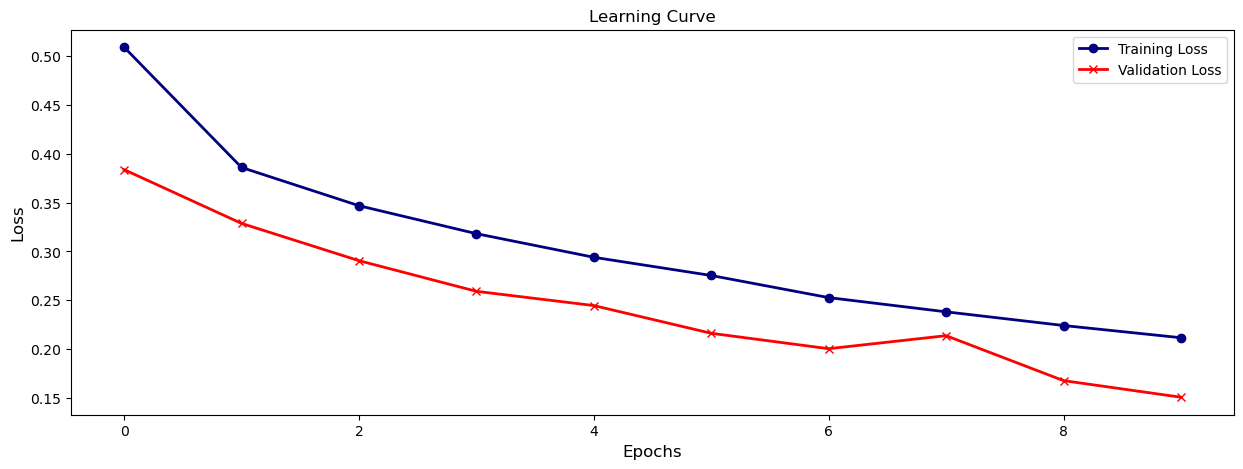

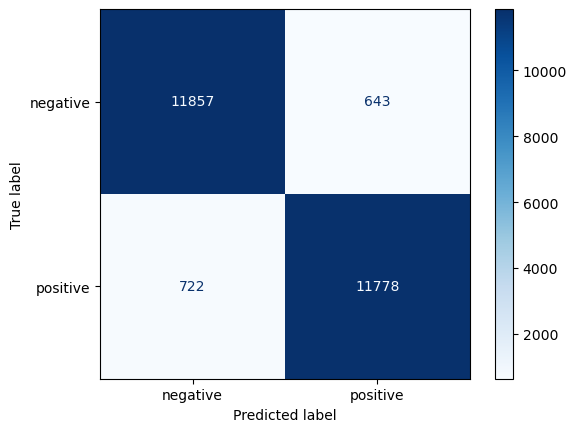


The training is completed!

Elapsed training time is: 1192.5688998699188 seconds (19.88 minutes)


In [23]:
# Call the training function
result = train(encoder, train_loader=train_dataloader, optimiser=optimiser, criterion=criterion, target_names=target_names, device=device, epochs=10)

The classification report is:
------------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.85      0.87      0.86     12500
    positive       0.87      0.85      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000


The confusion matrix is:
------------------------------------------------------------
[[10873  1627]
 [ 1882 10618]]


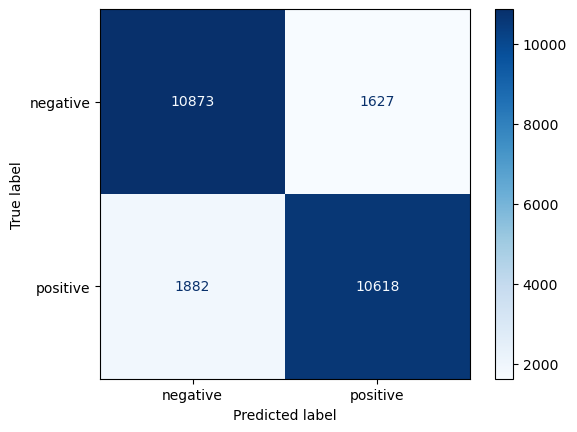


The testing is completed!


In [25]:
result = test(encoder, test_loader=test_dataloader, target_names=target_names, device=device, result_dict=result)

In [26]:
result['test']

{'negative': {'precision': 0.8524500196001568,
  'recall': 0.86984,
  'f1-score': 0.8610572163927935,
  'support': 12500.0},
 'positive': {'precision': 0.8671294405879951,
  'recall': 0.84944,
  'f1-score': 0.8581935744594867,
  'support': 12500.0},
 'accuracy': 0.85964,
 'macro avg': {'precision': 0.859789730094076,
  'recall': 0.85964,
  'f1-score': 0.8596253954261401,
  'support': 25000.0},
 'weighted avg': {'precision': 0.8597897300940761,
  'recall': 0.85964,
  'f1-score': 0.8596253954261401,
  'support': 25000.0}}